# Explore here

Airbnb en Nueva York
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

Paso 1: Carga del conjunto de datos
Puedes descargar el conjunto de datos directamente desde Kaggle.com o en el siguiente enlace: https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv. Almacena los datos en crudo en la carpeta ./data/raw.

Paso 2: Realiza un EDA completo
Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en la lección.

Paso 3: Guarda el conjunto de datos procesado
Después del EDA puedes guardar los datos en la carpeta ./data/processed. Asegúrate de agregar la carpeta de los datos en el .gitignore. Los datos al igual que los modelos no se deben subir a git.

PARTE 1

1. CONOCIENDO EL DATASET

In [2]:
#-------------------------------PARTE 1----------------------------------------------------
#librerías
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#data collection ok
#-------------------------1.métodos para conocer el dataset-------------------
df=pd.read_csv("../data/raw/AB_NYC_2019.csv")

df.info()
print("--------------------------------------------------------------------------------------")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
# revisando nulos
df.isnull().sum()


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Notas del dataset:
- la data tiene 48895 filas y 16 columnas
- la columna que tiene mas valores nulos es last_review y reviews_per_month
- los datos tienen 10 características numéricas y 5 características categóricas
- El ejercicios no tiene objetivo en concreto, a simple vista, los valores que pueden usarse para predecir puede ser room_type

2. ELIMINACIÓN DE DUPLICADOS

In [5]:
#-------------------------2. Eliminación de duplicados-------------------
duplicados = df.duplicated()
num_duplicados = duplicados.sum()

print(f"El dataset tiene {num_duplicados} filas duplicadas")

#si hubiera filas duplicadas 
#seleccionar duplicados
#df_duplicados = df[duplicados]
#usar el método drop.duplicated() para eliminar filas duplicadas
#df_sin_duplicados = df.drop_duplicates()

#-----------------control de duplicados----------------------------------
#chequeo de duplicados en host_id
df.duplicated(subset="host_id").sum()

El dataset tiene 0 filas duplicadas


np.int64(11438)

In [6]:
#chequeo de duplicados del campo id
df.duplicated(subset="id").sum()


np.int64(0)

In [7]:
#chequeo de duplicados del campo name
df.duplicated(subset="name").sum()

np.int64(989)

In [8]:
#chequeo de valor repetidos de host_id
df["host_id"].value_counts().head()

host_id
219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
Name: count, dtype: int64

In [9]:
#chequeo de valor repetidos de name
df["name"].value_counts().head()

name
Hillside Hotel                      18
Home away from home                 17
New york Multi-unit building        16
Brooklyn Apartment                  12
Loft Suite @ The Box House Hotel    11
Name: count, dtype: int64

In [10]:
#chequeo de duplicados por name+roomtype
df.duplicated(subset=["name", "room_type"]).sum()

np.int64(849)

Notas de control/análisis de duplicados:
- El dataset no tiene filas duplicadas
- El campo host_id tiene 11438 duplicados, lo que quiere decir que un host puede tener varias propiedades
- Se visualiza que el dataset incluye filas únicas por listing porque no hay duplicados en id.
- Se encuentran duplicados en columna name, esto quiere decir que se reutilizan los nombres de las propiedades
- Se revisa duplicados por name+roomtype y se conluye que este no define la unicidad de las filas, se puede decir que los registros únicos registran por id.

3. SELECCIÓN DE ATRIBUTOS RELEVANTES

In [11]:
#-------------------------3. Selección de atributos relevantes-------------------
df.drop(["id", "host_id","name", "host_name","last_review","longitude","latitude"], axis = 1, inplace = True)

df.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0


Notas de selección de atributos:
- Se excluyen las columnas id, host_id, name, host_name, last_review, longitude y latitude por tener valores individuales, no valen para generalizar.
- No se elimina ninguna columna por motivo de alto porcentaje de nulos.
- Se evaluó eliminar reviews_per_month que tienen el 20% de nulos, pero se decidió omantener

4. ANÁLISIS UNIVARIANTE

In [12]:
#-------------------------4. Análisis univariante-----------------------
#chequeo de campos en df
df.info()
print("==============================================================")
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   room_type                       48895 non-null  str    
 3   price                           48895 non-null  int64  
 4   minimum_nights                  48895 non-null  int64  
 5   number_of_reviews               48895 non-null  int64  
 6   reviews_per_month               38843 non-null  float64
 7   calculated_host_listings_count  48895 non-null  int64  
 8   availability_365                48895 non-null  int64  
dtypes: float64(1), int64(5), str(3)
memory usage: 3.4 MB


(48895, 9)

4.1. Análisis sobre variables categóricas

In [13]:
# ---------------------------Análisis sobre variables categóricas
# revisión de valores repetidos por neighbourhood_group
df.neighbourhood_group.value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [14]:
#revisión de valores repetidos por room_type
df.room_type.value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [15]:
#revisión de valores repetidos por room_type
df.neighbourhood.value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

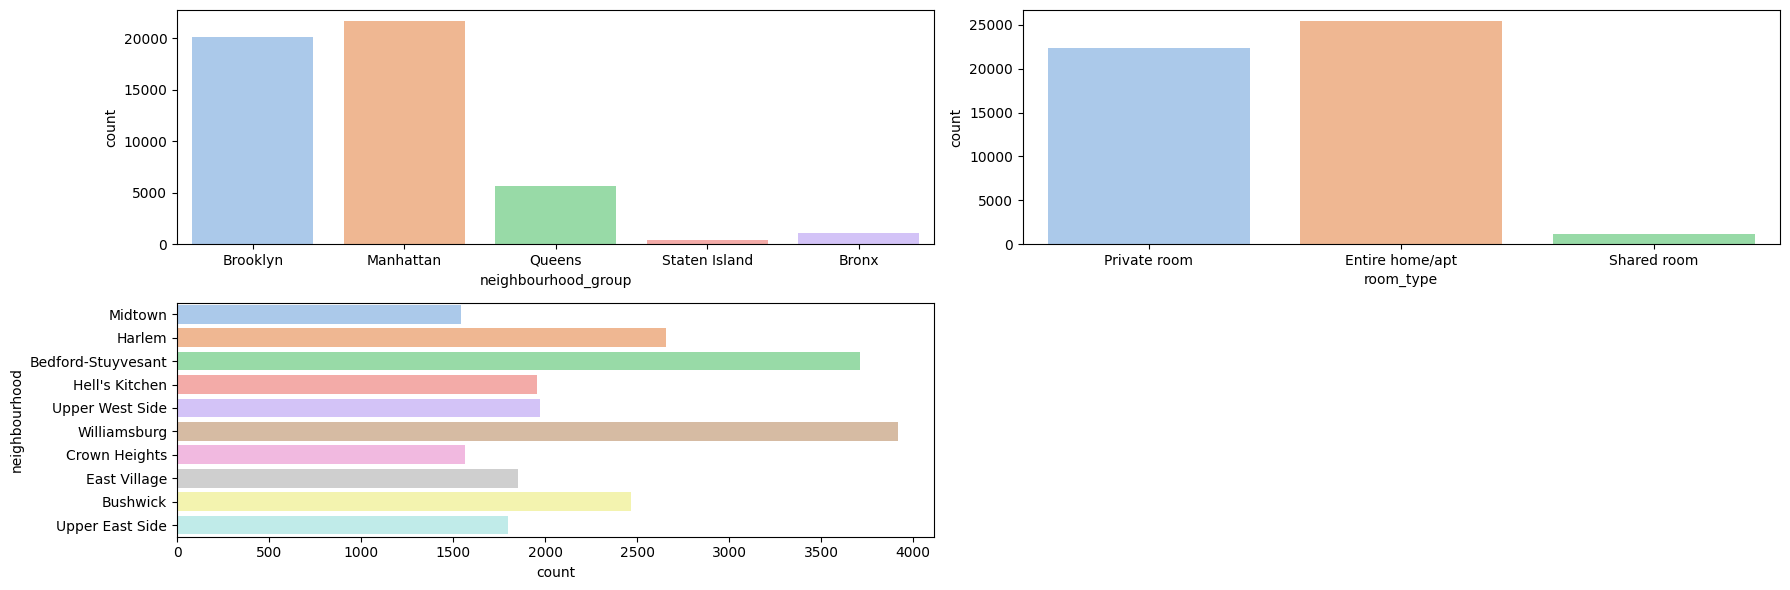

In [16]:
#--------------------------------Visualización de datos de variables categóricas-------------
#seleccion de top 10 de neighbouhood
top_neighbourhood=df["neighbourhood"].value_counts().head(10).index

df_top = df[df["neighbourhood"].isin(top_neighbourhood)]

#script para los 3 gráficos, barras 
fig, axis = plt.subplots(2, 2, figsize = (18, 6))

sns.countplot(ax = axis[0,0], data = df, x = "neighbourhood_group", palette='pastel',hue="neighbourhood_group" ,legend=False)
sns.countplot(ax = axis[0,1], data = df, x = "room_type", palette='pastel',hue="room_type",legend=False)
sns.countplot(ax = axis[1,0], data = df_top, y = "neighbourhood",  palette='pastel', hue="neighbourhood",legend=False)

fig.delaxes(axis[1, 1])
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Conclusiones de variables categóricas:
- Neighbourhood_grupo:
    - Manhattan y Brooklyn tienen la mayor concentración de alquileres que en las demás zonas.
- Room_type:
    - Existe alta oferta en alquileres de tipo entire home/apt y private_room.
    - Hay baja oferta en habitaciones compartidas.

- Neighbourhood:
    - Dentro edl top 10 de neighbourhood Williamsburg y Bedford-Stuyvesant destacan como los barrios con mayor oferta.



4.2. Análisis sobre variables numéricas

In [17]:
#valores estadísticos de variables númericas
df[["price", "minimum_nights","availability_365","number_of_reviews"]].describe()

,price,minimum_nights,availability_365,number_of_reviews
count,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,112.781327,23.274466
std,240.154170,20.510550,131.622289,44.550582
min,0.000000,1.000000,0.000000,0.000000
25%,69.000000,1.000000,0.000000,1.000000
50%,106.000000,3.000000,45.000000,5.000000
75%,175.000000,5.000000,227.000000,24.000000
max,10000.000000,1250.000000,365.000000,629.000000


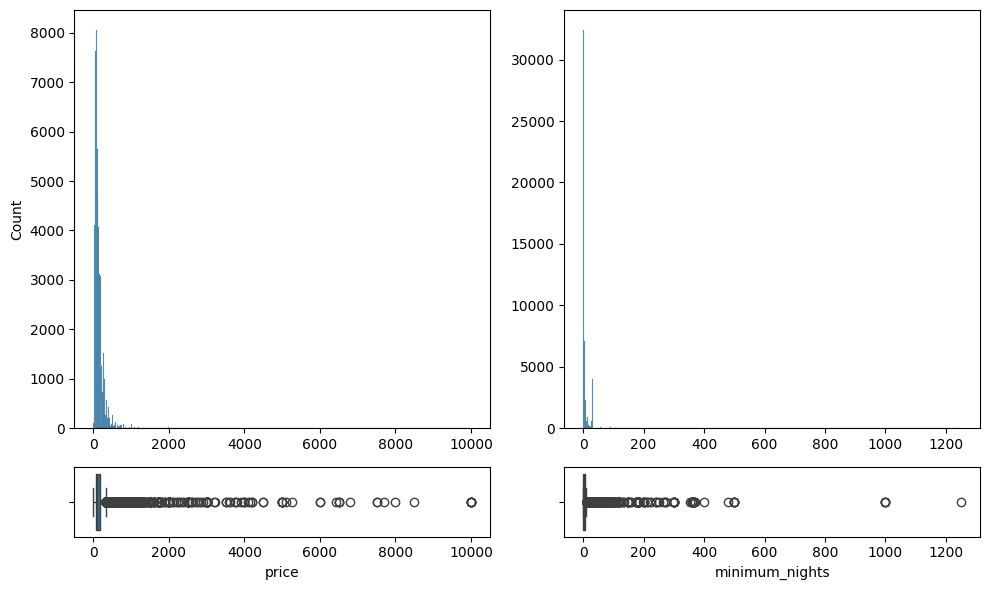

In [18]:
# ---------------------------Análisis sobre variables numéricas
fig, axis = plt.subplots(2,2, figsize = (10, 6), gridspec_kw={'height_ratios': [6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja

#visualización de price
sns.histplot(ax = axis[0,0], data = df, x = "price").set(xlabel = None)
sns.boxplot(ax = axis[1,0], data = df, x = "price")

#visualización de minimun nights
sns.histplot(ax = axis[0, 1], data = df, x = "minimum_nights").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "minimum_nights")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Análisis numéricas:

En este caso se evalúa la distribución de price y minimun nights.
price:
- Se visualiza muchísimos outliers en price, el valor máximo es 10000 y la media de este campo es 152.7
- Se evidencia que hay propiedades que tienen precio 0, esto se puede interpretar que hay errores de registro o valores imputados en lugar de nulos.
- 152.7>106, price tiene sesgo hacia la derecha, ya que la media es mayor a la mediana

minimun_nights:
- Se visualizan muchísimos outliers en minimun nights.
- La media es aprox. 7 noches y la mediana es 3, por lo que lo que se interpreta que mayormente los alquileres están destinado para estancias cortas. Sin embargo hay valor atípicos (1250), lo que quiere decir que esto puede suceder por alguna configuración adhoc correspondiente al alquiler de la propiedad. Además los outliers influyen en la media.
- No se evidencian valores 0, el valor mínimo es 1, por lo cual se puede decir que hay propiedades que se alquilan mínimo una noche.
- 7>3, minimun_nights tiene sesgo hacia la derecha, ya que la media es mayor a la mediana.


nota de sesgo:
Si media > mediana → sesgo a la derecha
Si media < mediana → sesgo a la izquierda

5. ANÁLISIS MULTIVARIANTE

5.1. Análisis numérico-numérico

Price- minimun_nights

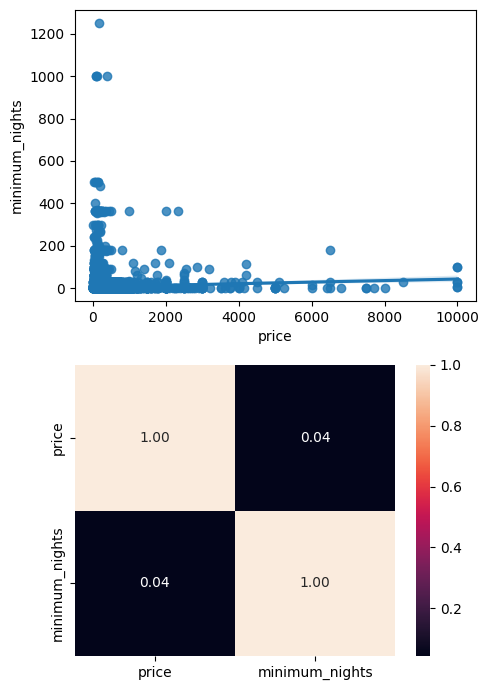

In [19]:
#price-minimum_nights
fig, axis = plt.subplots(2, 1, figsize = (5, 7))

# Crear un diagrama de dispersión múltipleS
sns.regplot(ax = axis[0], data = df, x = "price", y = "minimum_nights")
sns.heatmap(df[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()


- Se visualiza que hay correlación muy debil entre price y minimun_nights ya que el valor en el mapa de calor es 0.04, no es un valor cercano a 1.
- Por otro lado, en el gráfico de dispersión se evidencia la concentración de datos en valores bajos y muchos valores atípicos.

Price- availability_365

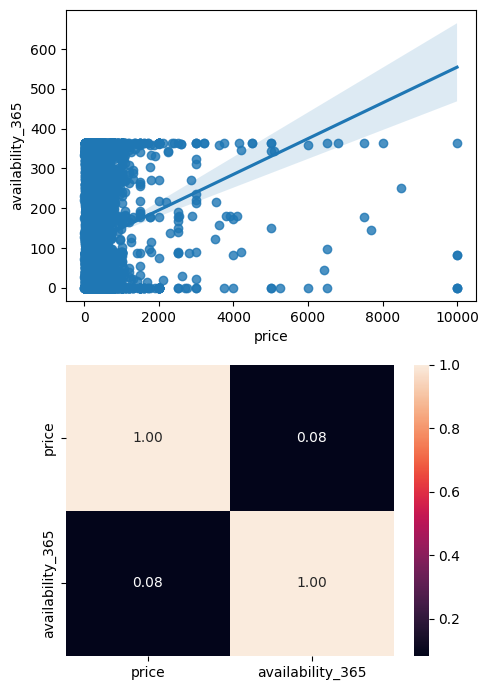

In [20]:
#price-availability_365
fig, axis = plt.subplots(2, 1, figsize = (5, 7))

# Crear un diagrama de dispersión múltiples
sns.regplot(ax = axis[0], data = df, x = "price", y = "availability_365")
sns.heatmap(df[["price", "availability_365"]].corr(), annot = True, fmt = ".2f", ax = axis[1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Se visualiza que hay correlación muy debil entre price y availability_365 ya que el valor en el mapa de calor es 0.08, no es un valor cercano a 1.
- El diagrama de dispersión presenta una tendencia ascendente, existe una alta dispersión y presencia de valores atípicos.

Price- number_of_reviews

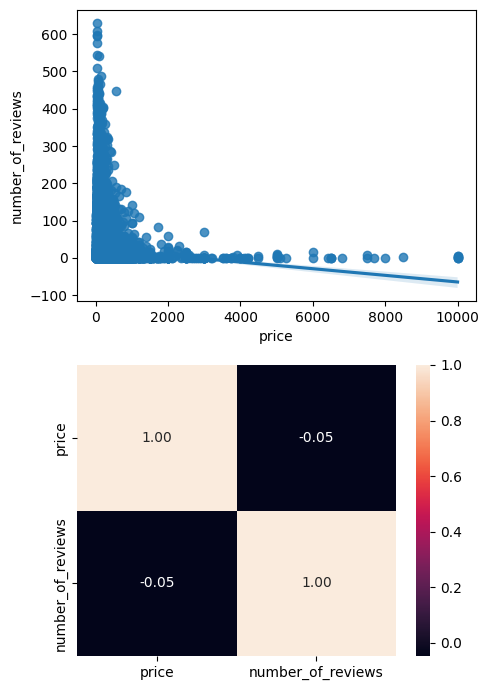

In [21]:
#price-number_of_reviews
fig, axis = plt.subplots(2, 1, figsize = (5, 7))

# Crear un diagrama de dispersión múltiples
sns.regplot(ax = axis[0], data = df, x = "price", y = "number_of_reviews")
sns.heatmap(df[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Se visualiza que hay correlación muy debil entre price y number_of_reviews ya que el valor en el mapa de calor es 0.05, no es un valor cercano a 1.
- El diagrama de dispersión presenta una ligera tendencia descendente, existe una alta dispersión y presencia de valores atípicos. Además, se ve que los alojamientos con precio bajos presentan más cantidad de reviews. Por último, la dispersión de los datos hacen díficil encontrar una relación lineal entre las variables.

5.2. Análisis categórico- categórico

room_type-neighbourhood_group              

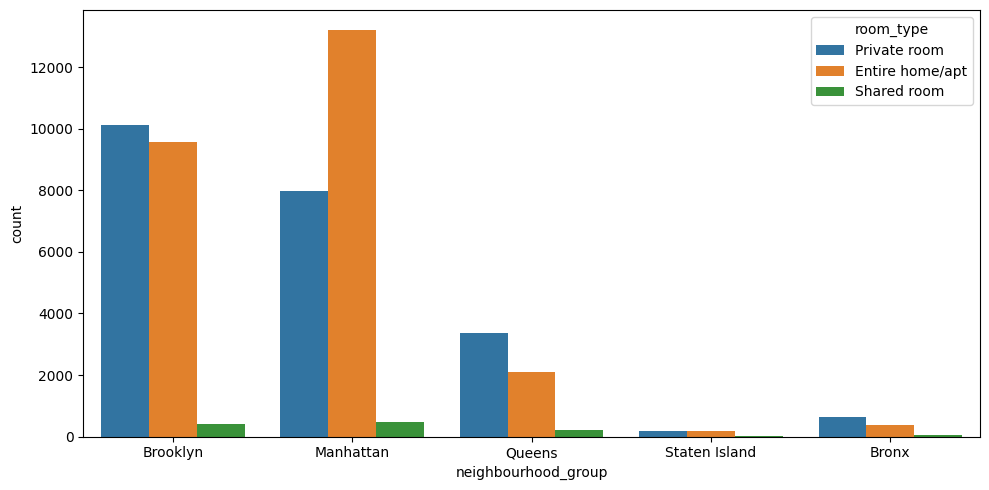

In [22]:
fig, axis = plt.subplots( figsize = (10, 5))

sns.countplot( data = df, x = "neighbourhood_group", hue = "room_type")

plt.tight_layout()

plt.show()

Conclusiones:
- Si bien Manhattan y Brooklyn son las zonas con más alquileres, en manhattan se ofertan más espacios de tipo entire home, mientras que en brooklyn hay cantidad más equilibrada de alquileres de tipo private_room y entire home.
- Queens, staten island y bronx presentan menos alquileres, sin embargo se visualiza que estas zonas ofrecen más alquileres de tipo private_room.

Análisis de correlaciones

El objetivo del análisis de correlaciónes con datos categóricos-categóricos es descubrir patrones y dependencias entre variables, lo que ayuda a entender cómo interactúan dentro de un conjunto de datos.

Este análisis tiene como objetivo determinar si y cómo las categorías de una variable están relacionadas con las categorías de otra.

In [23]:
#Se factoriza room_type
df["room_type_n"] = pd.factorize(df["room_type"])[0]

# Factorizar neighbourhood_group
df["neighbourhood_group_n"] = pd.factorize(df["neighbourhood_group"])[0]

In [24]:
df.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n
0,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365,0,0
1,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355,1,1
2,Manhattan,Harlem,Private room,150,3,0,NaN,1,365,0,1
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194,1,0
4,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0,1,1


In [25]:
#value.count para visualizar los valores de la factorización
print(df.room_type_n.value_counts())
print("=========================================")

#Para visualizar los valores correspondientes a la factorización
print(df.room_type.value_counts())

room_type_n
1    25409
0    22326
2     1160
Name: count, dtype: int64
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


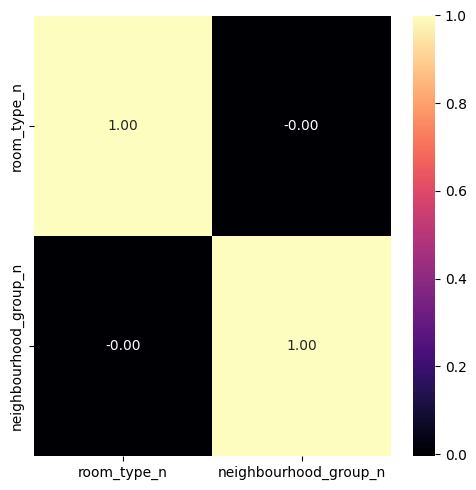

In [26]:
fig, axis = plt.subplots(figsize=(5,5))

sns.heatmap(
    df[["room_type_n", "neighbourhood_group_n"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="magma"
)

plt.tight_layout()
plt.show()

Conclusiones:
- Se realiza la factorización de variables room_type y neighbourhood_group, para colocar etiquetas numéricas a los valores.
- No se identifica correlación entrer ambas variables, ya que el valor optenido en el mapa de calor es 0.
- Se descartó usar nneighbourhood porque tiene muchísimas categorías. se entiendo que esto dificulta la interpretación de los resultados.
- Se entiende que el mapa de calor ayuda a identificar la correlación de variables numéricas, aquí se realiza la factorización de las variables categóricas para realizar el mismo análisis, sin embargo no se encontraron resultados relevantes.

5.3. Análisis numérico- categórico

Para ello, simplemente hemos de calcular las correlaciones entre las variables, ya que es el mayor indicativo sobre las relaciones.

Otro elemento que nos puede ser de mucha ayuda es obtener las relaciones dos a dos entre todos los datos del dataset.

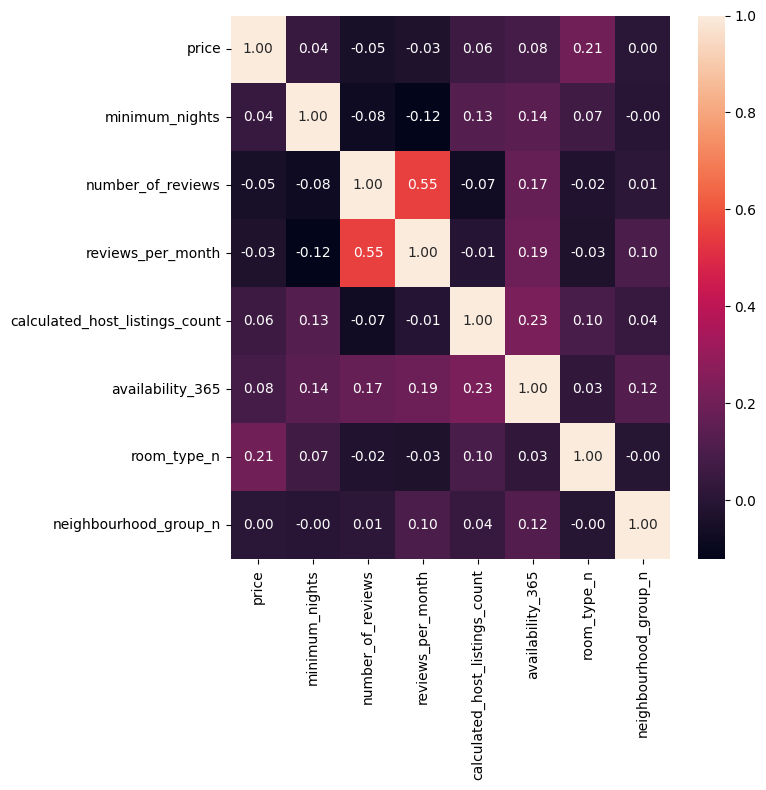

In [27]:
fig, axis = plt.subplots(figsize = (8, 8))

sns.heatmap(df[["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365","room_type_n","neighbourhood_group_n"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

Conclusiones:
- Se usaron las variables categóricas factorizaadas room_type y neighbouhood_group para usarlas en el previo análisis de correlación.
- La correlación entre las variables categóricas factorizadas y las numéricas fueron bajas. Por lo que no se encontraron resultados relevantes.
- Room_type_n y price presentan una ligera correlación postitiva. lo que puede indicar diferencias de precios por tipo de alojamiento.
- Si bien no hay correlación fuerte, number_of_reviews y reviews_per_month (0.55) indican una relación positiva moderada.

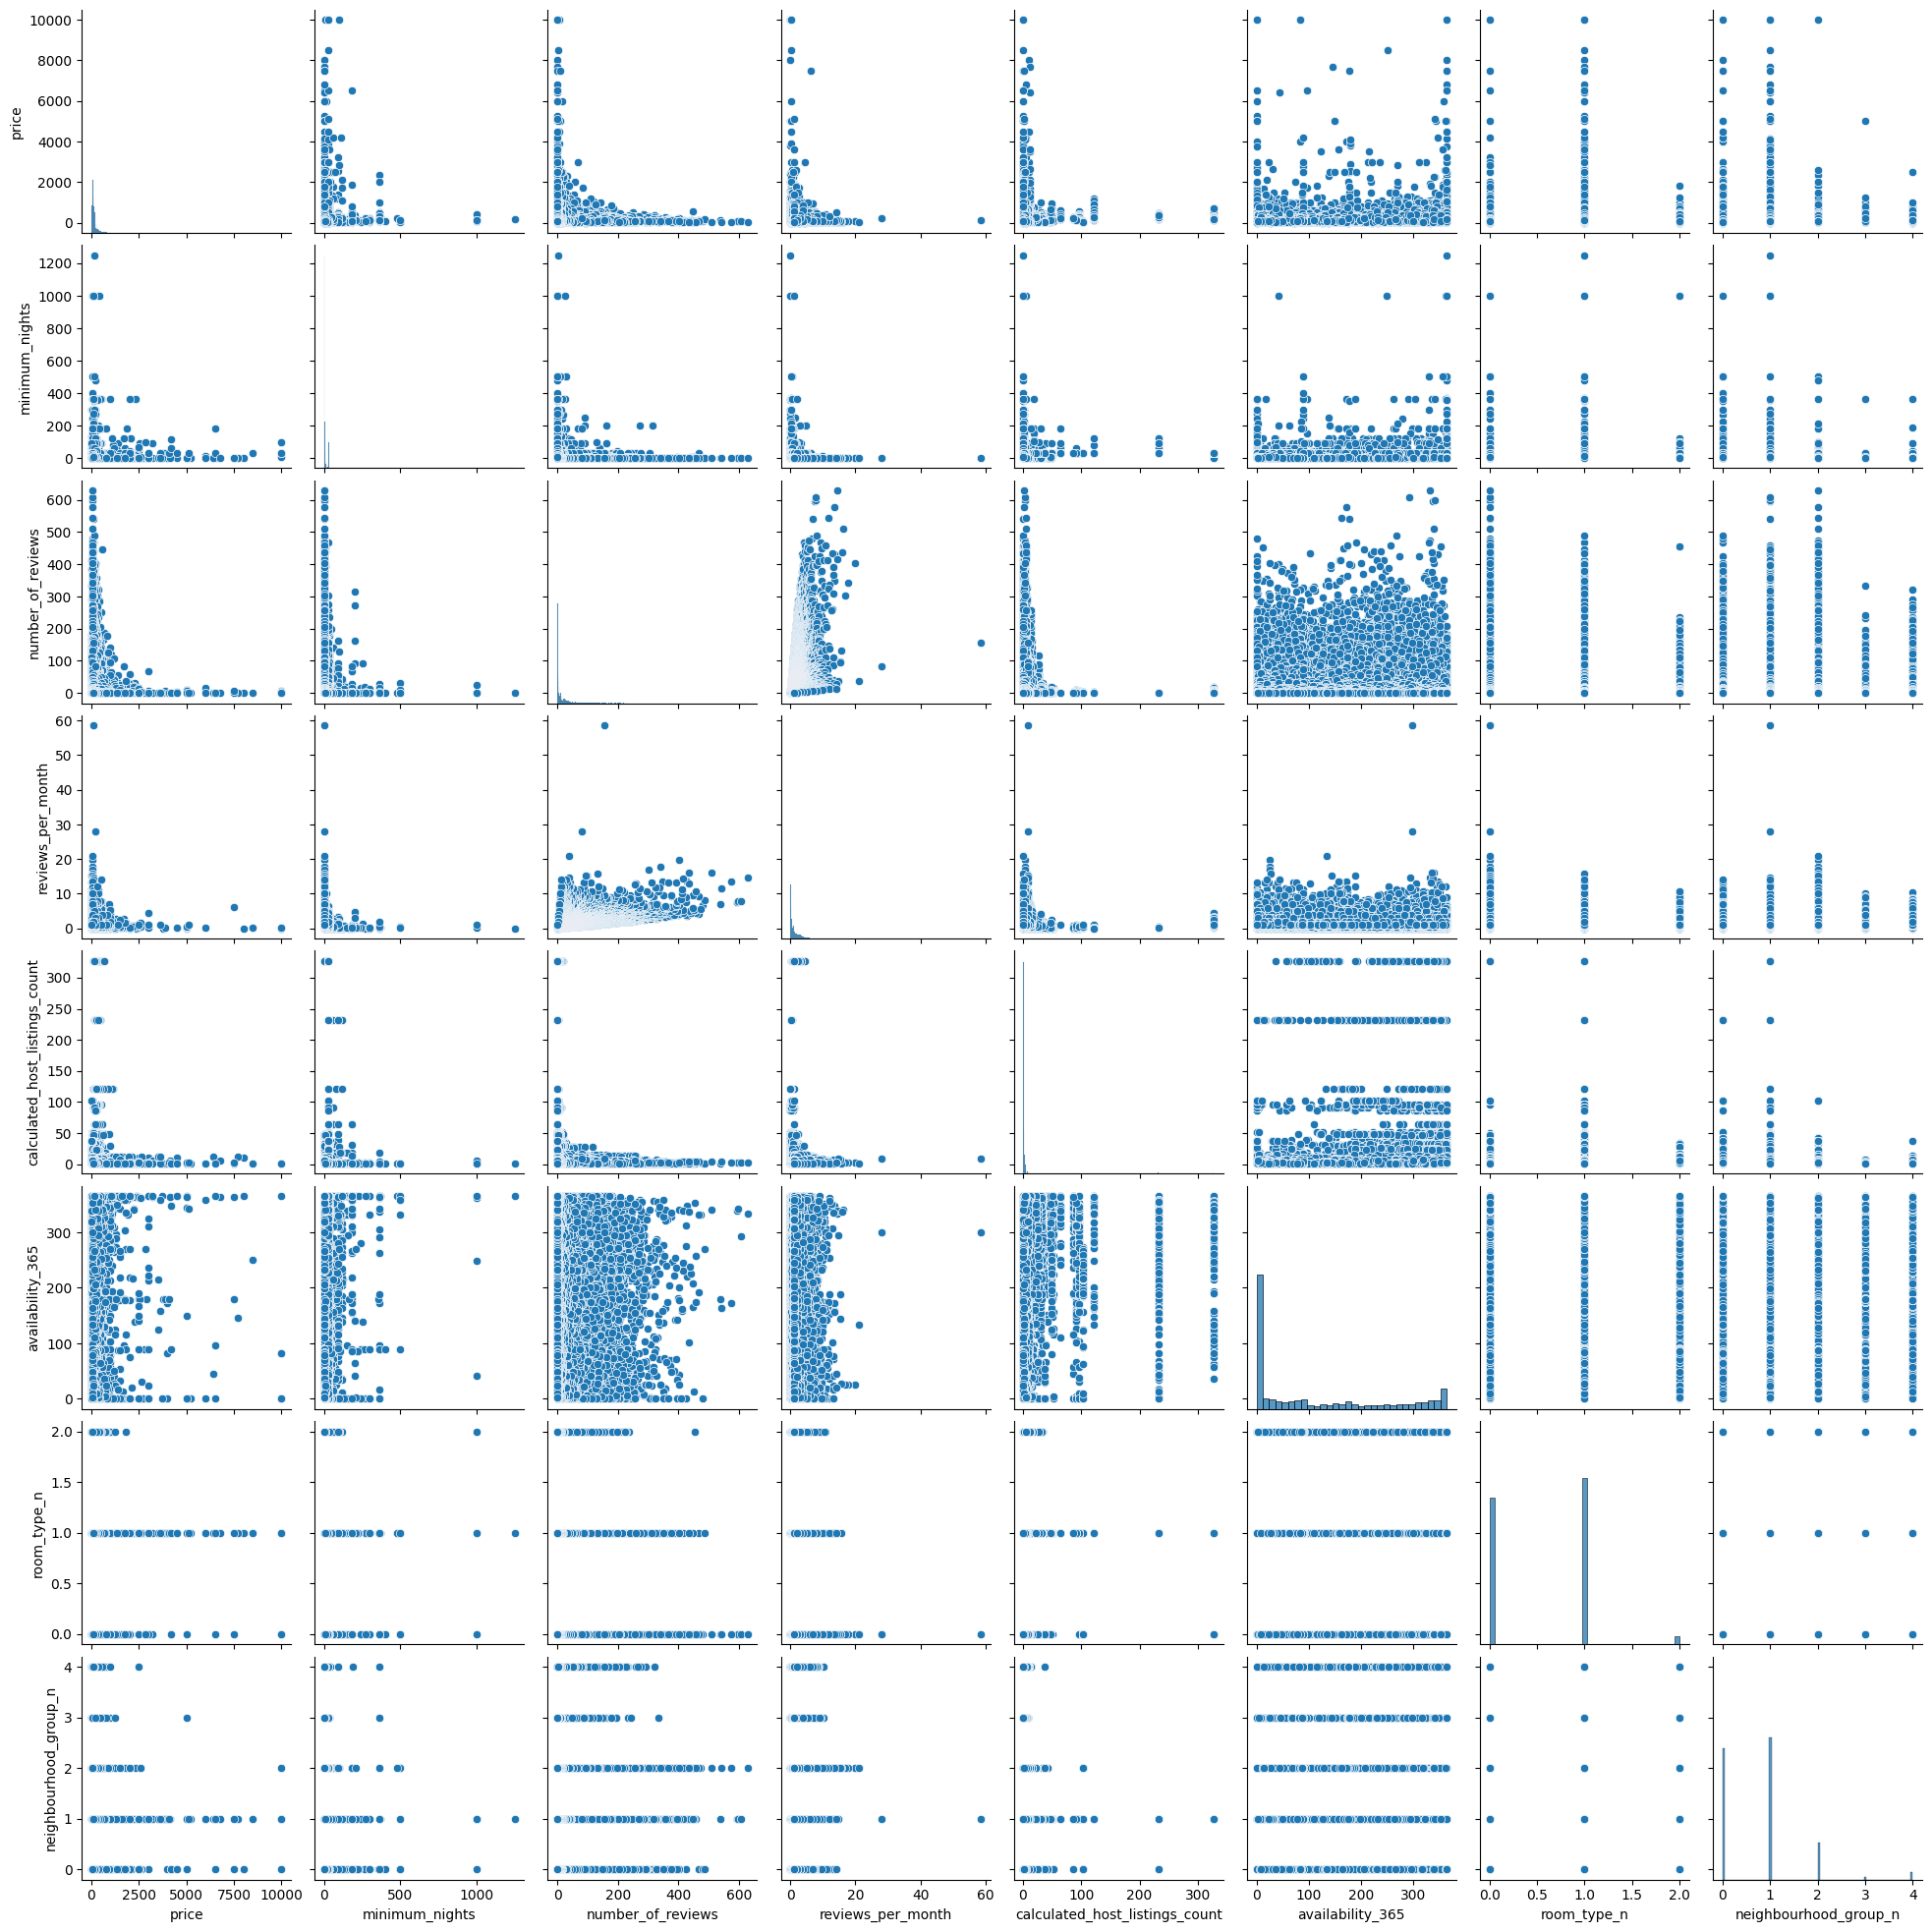

In [28]:
sns.pairplot(data = df)

PARTE 2
1. Valores atípicos

Un valor atípico (outlier) es un punto de datos que se desvía significativamente de los demás.

Es un valor que es notablemente diferente de lo que sería de esperar dada la tendencia general de los datos.

Estos outliers pueden ser causados por errores en la recolección de datos, variaciones naturales en los datos, o pueden ser indicativos de algo significativo, como una anomalía o evento extraordinario.

- **Mantenerlos**. podría ser una política que en ciertos casos tuviera sentido.
- **Eliminarlos**. aquellas instancias que cuenten con características atípicas se eliminan del conjunto de datos. Sin embargo, si hay muchos valores atípicos, esta estrategia puede causar que se pierda gran parte de la información disponible.
- **Reemplazarlos**. Si no queremos eliminar instancias completas por la presencia de outliers en una de sus características, podemos reemplazarlos tomándolos en cuenta como valores faltantes y reutilizando la política.

In [29]:
df.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n
count,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327,0.567113,0.786911
std,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289,0.541249,0.844386
min,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,0.000000
25%,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000,0.000000,0.000000
50%,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000,1.000000,1.000000
75%,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000,1.000000,1.000000
max,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,2.000000,4.000000


- Price: como se mencionó en el análisis de numéricas la media de precios es 152 pero su valor máximo es 10000 por lo que  podemos decir que muestra valores ápiticos muy altos. Además, tiene valores 0, por lo que puede
- Minimun_nights: Como se mencionó en el análisis de numéricas la media de valores es 7, sin embargo muestra valores atípicos muy altos, porque el máximo es 1250. Se dijo que esto podría deberse por una configuración específica correspondiente al alquiler de la vivienda. Podría estar relacionado con alquileres de larga estancia o configuraciones particulares del anuncio.
- Los campos que muestran valores atípicos muy altos son price, minimun_ninghts, number_of_reviews,reviews_per_month y calculated_host_listing_count

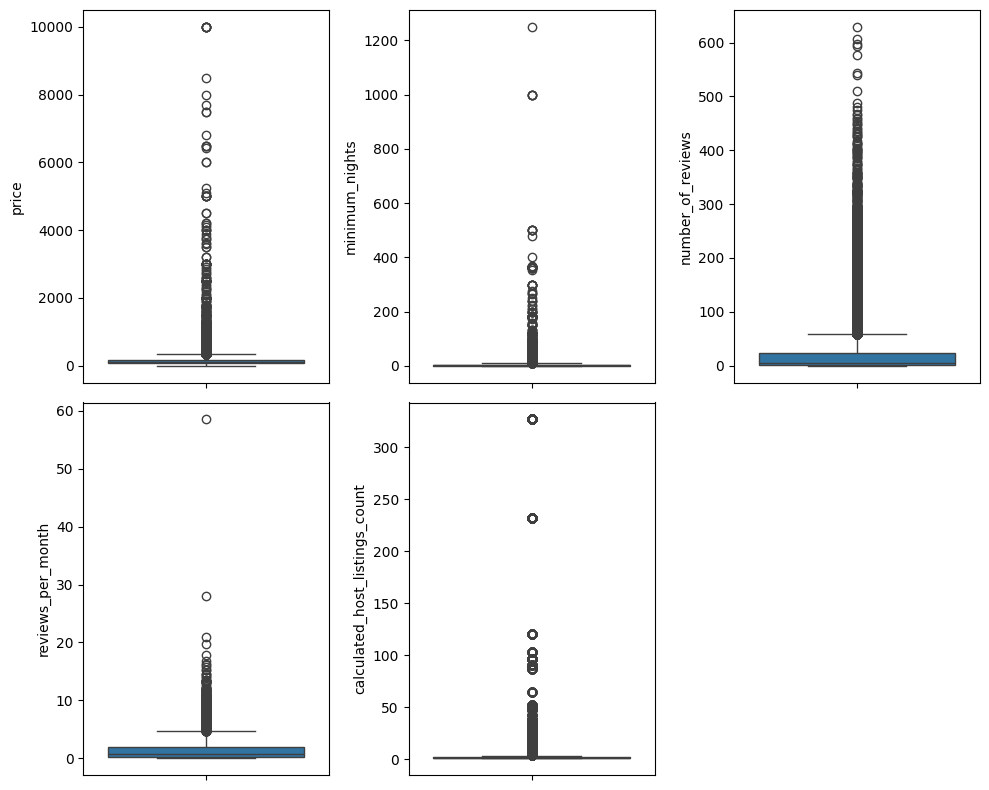

In [30]:
#boxplot para visualización de valores atípicos
fig, axis = plt.subplots(2, 3, figsize = (10, 8))

sns.boxplot(ax = axis[0, 0], data = df, y = "price")
sns.boxplot(ax = axis[0, 1], data = df, y = "minimum_nights")
sns.boxplot(ax = axis[0, 2], data = df, y = "number_of_reviews")
sns.boxplot(ax = axis[1, 0], data = df, y = "reviews_per_month")
sns.boxplot(ax = axis[1, 1], data = df, y = "calculated_host_listings_count")

fig.delaxes(axis[1, 2])
plt.tight_layout()

plt.show()

Se visualiza que todas son variaibles afectadas con valores atípicos.
A continuación se evaluará la eliminación de atípicos variable a variable.

Eliminación atípicos- price

In [31]:
#Para price
#Calcular el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 334.0 y -90.0, con un rango intercuartílico de 106.0


Según dicho método, se podría eliminar los registros que tienen importe mayor a 334. Pero este resultado no parece relevante, no es extraño el precio de un aribnb cueste mas de 334.

A continuación, se hará una búsqueda de outliers más extremas:

In [32]:
# Definir los límites inferior y superior, se utiliza 3* en ves de 1.5* que se usaba en el script anterior
lower_limit = Q1 - 3 * IQR
upper_limit = Q3 + 3 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 493.0 y -249.0, con un rango intercuartílico de 106.0


Según el script, los valores más extremos están por enncima de 493

In [33]:
precios_altos = df[df["price"] >= 493]

precios_altos

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n
85,Brooklyn,Brooklyn Heights,Entire home/apt,800,1,25,0.24,1,7,1,0
103,Manhattan,West Village,Entire home/apt,500,4,46,0.55,2,243,1,1
233,Manhattan,SoHo,Entire home/apt,500,4,94,0.99,1,329,1,1
242,Manhattan,Chelsea,Entire home/apt,500,2,35,0.34,1,348,1,1
299,Manhattan,Little Italy,Entire home/apt,575,2,191,1.88,1,298,1,1
...,...,...,...,...,...,...,...,...,...,...,...
48697,Manhattan,Upper West Side,Entire home/apt,750,4,0,NaN,1,174,1,1
48740,Brooklyn,Brooklyn Heights,Entire home/apt,550,3,1,1.00,1,230,1,0
48744,Brooklyn,Williamsburg,Entire home/apt,499,30,0,NaN,1,365,1,0
48757,Manhattan,Tribeca,Entire home/apt,700,3,0,NaN,1,37,1,1


In [34]:
precios_altos.room_type.value_counts()

room_type
Entire home/apt    1139
Private room        178
Shared room          11
Name: count, dtype: int64

Según los script anteriores, si se considera que los valores de price mayores a 493 son outliers, tomando en cuenta que estos son 1325 filas, significa que equivalen 2.6% aprox del dataset. 

Además segun el script para buscar como se distribuyen esos "outliers" por roomtype, la mayoría de datos se concentran en entirehome, por lo que hay que tener cuidadi porque en el análisis de categóricos se encontró que en los neighbourhood_group (manhattan y broklyn) hay una mayor concentración de alojamiento de este tipo.

Finalmente, se decide mantener los valores atípicos.

Eliminación atípicos- minimum_nights

Se realiza el análisis similar al que se realizó con price.

In [35]:
#Calcular el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1 = df['minimum_nights'].quantile(0.25)
Q3 = df['minimum_nights'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit_m = Q1 - 1.5 * IQR
upper_limit_m = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit_m, 2)} y {round(lower_limit_m, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 11.0 y -5.0, con un rango intercuartílico de 4.0


In [36]:
# Definir los límites inferior y superior, se utiliza 3* en ves de 1.5* que se usaba en el script anterior
lower_limit_m = Q1 - 3 * IQR
upper_limit_m = Q3 + 3 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit_m, 2)} y {round(lower_limit_m, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 17.0 y -11.0, con un rango intercuartílico de 4.0


In [37]:
noches_altos = df[df["minimum_nights"] >= 17]

noches_altos

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n
6,Brooklyn,Bedford-Stuyvesant,Private room,60,45,49,0.40,1,0,0,0
14,Manhattan,West Village,Entire home/apt,120,90,27,0.22,1,0,1,1
36,Brooklyn,Bedford-Stuyvesant,Private room,35,60,0,NaN,1,365,0,0
45,Brooklyn,Prospect-Lefferts Gardens,Entire home/apt,150,29,11,0.49,1,95,1,0
55,Brooklyn,Williamsburg,Entire home/apt,150,30,105,0.90,1,30,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48810,Manhattan,Upper West Side,Private room,75,30,0,NaN,1,90,0,1
48843,Brooklyn,Bedford-Stuyvesant,Private room,45,29,0,NaN,2,341,0,0
48871,Manhattan,Harlem,Private room,35,29,0,NaN,2,31,0,1
48879,Brooklyn,Williamsburg,Entire home/apt,120,20,0,NaN,1,22,1,0


In [38]:
noches_altos.room_type.value_counts()

room_type
Entire home/apt    3826
Private room       1662
Shared room         115
Name: count, dtype: int64

Conclusiones:
Se realiza un chequeo de outliers y resulta que en el primer escenario los ouliers se proponen ser mayores a 11. Sin embargo se aplica un método para buscar valores más extremos, y en dicho escenario 2, el script dice que los outliers se podrían considerar aquellos mayores a 17.

En el escenario 2, se visualiza la distrribución de los registros minimum_nights >17 según room_type y vemos que esto equivale a un 11% del dataset. Además la mayoria de registros "outliers" se concentran en entire_home, el cual se considera una categoría relevante.

Finalmente, se decide no eliminar outliers.

Eliminación atípicos-calculated_host_listings_count

In [39]:
#Calcular el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1 = df['calculated_host_listings_count'].quantile(0.25)
Q3 = df['calculated_host_listings_count'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit_host_lis = Q1 - 1.5 * IQR
upper_limit_host_lis = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit_host_lis, 2)} y {round(lower_limit_host_lis, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 3.5 y -0.5, con un rango intercuartílico de 1.0


In [40]:
# Definir los límites inferior y superior, se utiliza 3* en ves de 1.5* que se usaba en el script anterior
lower_limit_host_lis = Q1 - 3 * IQR
upper_limit_host_lis = Q3 + 3 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit_host_lis, 2)} y {round(lower_limit_host_lis, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 5.0 y -2.0, con un rango intercuartílico de 1.0


In [41]:
host_list_altos = df[df["calculated_host_listings_count"] >= 5]

host_list_altos

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n
0,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365,0,0
21,Brooklyn,Park Slope,Private room,130,2,130,1.09,6,347,0,0
22,Brooklyn,Park Slope,Private room,80,1,39,0.37,6,364,0,0
23,Brooklyn,Park Slope,Private room,110,2,71,0.61,6,304,0,0
92,Brooklyn,Clinton Hill,Private room,98,7,16,0.20,6,185,0,0
...,...,...,...,...,...,...,...,...,...,...,...
48857,Queens,Woodhaven,Entire home/apt,85,3,0,NaN,6,300,1,2
48867,Brooklyn,Gravesend,Shared room,25,1,0,NaN,6,338,2,0
48868,Brooklyn,Gravesend,Shared room,25,7,0,NaN,6,365,2,0
48878,Queens,Elmhurst,Private room,45,1,0,NaN,5,172,0,2


In [42]:
host_list_altos.room_type.value_counts()

room_type
Entire home/apt    2703
Private room       2562
Shared room         376
Name: count, dtype: int64

Conclusiones:

Se realiza un análisis de outliers sobre la variable calculated_host_listings_count, la cual se entiende que representa la cantidad de alojamientos registrados por un mismo host dentro de la plataforma.

Se realiza un chequeo de outliers y resulta que en el primer escenario los ouliers se proponen ser mayores a 3.5. Sin embargo se aplica un método para buscar valores más extremos, y en dicho escenario 2, el script dice que los outliers se podrían considerar aquellos mayores a 5.

En el escenario 2, se visualiza la distrribución de los registros calculated_host_listings_count >5 según room_type y vemos que esto equivale a un 11.5% del dataset. Además la mayoria de registros "outliers" se concentran en entire_home, el cual se considera una categoría relevante.

Por último, se decide no eliminar outliers.


Conclusión final: se analizaron los valores atipicos de 3 variables que se consideraron mas relevantes en valores extremos según los boxplots (price, minimum_nights y calculated_host_listings_count) y no se eiminaron valores atípicos.

2. Valores faltantes

Un valor faltante (missing value) es no tener valor asignado en la observación de una variable específica.

Pueden surgir por muchas razones. Por ejemplo, podría haber un error en la recopilación de datos, alguien podría haberse negado a responder una pregunta en una encuesta, o simplemente podría ser que cierta información no esté disponible o no sea aplicable.
- **Eliminarlos**. Similar al caso anterior de los outliers. Recomendable solo si el porcentaje es bajo.

- **Imputación**: Para rellenar los valores faltantes en una variable numérica, normalmente el procedimiento es utilizar los valores estadísticos de la muestra.

Cuando la columna es categórica, normalmente se suelen rellenar con el valor más frecuente.

También se puede recurrir a imputaciones obteniendo relaciones con otras variables.

In [43]:
df.isnull().sum().sort_values(ascending=False)

reviews_per_month                 10052
neighbourhood                         0
neighbourhood_group                   0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
calculated_host_listings_count        0
availability_365                      0
room_type_n                           0
neighbourhood_group_n                 0
dtype: int64

In [44]:
df.isnull().sum().sort_values(ascending=False) / len(df)

reviews_per_month                 0.205583
neighbourhood                     0.000000
neighbourhood_group               0.000000
room_type                         0.000000
price                             0.000000
minimum_nights                    0.000000
number_of_reviews                 0.000000
calculated_host_listings_count    0.000000
availability_365                  0.000000
room_type_n                       0.000000
neighbourhood_group_n             0.000000
dtype: float64

Se visualiza que el único campo que tiene nulos es reviews_per_month, esto significa que es un dato que representa que no ha habido esta actividad en dichas propiedades, se traduce a que hay alojamientos sin reviews. en conclusión, se decide no eliminar sino imputar con 0.

In [45]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [46]:
#validar la imputación
df.isnull().sum().sort_values(ascending=False)

neighbourhood_group               0
neighbourhood                     0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
room_type_n                       0
neighbourhood_group_n             0
dtype: int64

Se visualiza que ya no existen valores faltantes.

2. Ingeniería de atributos

La **ingeniería de características** (*feature engineering*) es el proceso de utilizar el conocimiento del dominio de datos para crear y transformar características o variables que hacen que los algoritmos de Machine Learning funcionen de manera más eficiente.

La ingeniería de características puede llevar mucho tiempo porque incluye una serie de procesos, como:

- Rellenar valores faltantes dentro de una variable.
- Crear o extraer nuevas características de las disponibles en tu conjunto de datos.
- Codificación de variables categóricas en números (encoding).
- Transformación de variables.

Otro uso típico en esta ingeniería es la de la obtención de nuevas características mediante la "fusión" de dos o más ya existentes.

------------------------------------------------------------------------------------

*Transformar datos existentes en variables más informativas.*

Notas: Del análisis previo de elimimación atípicos y faltantes. 
Se propone agrupar por host con muchas proppiedades, para esto se usaría la variable calculated_host_listings_count. 
Por otro lado, se puede hacer agrupación por precios como propiedades a alquilar con precio bajo, medio y caro.
Además, se puede agrupar por disponibilidad de las propiedades, disponibilidad corta, media y larga. (con la variable availability_365)

primero. Agrupación por calculateed_host_listing_count >5 (dueños con más de 5 propiedades)

In [47]:
df["mayores_host"] = df["calculated_host_listings_count"] > 5


df.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n,mayores_host
0,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365,0,0,True
1,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355,1,1,False
2,Manhattan,Harlem,Private room,150,3,0,0.00,1,365,0,1,False
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194,1,0,False
4,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0,1,1,False


Notas: se agrupan los host con multiples propiedades
Se busca diferenciar los host particulares y profesionales.

Segundo. Agrupar price por barato, medio y caro 

In [48]:
df["price_grupo"] = pd.qcut(
    df["price"],
    q = 3,
    labels = [0,1,2])

df[["price", "price_grupo"]].head()

,price,price_grupo
0,149,1
1,225,2
2,150,1
3,89,1
4,80,0


In [49]:
#visualizar los límites de cada categoría
pd.qcut(df["price"], q=3).value_counts()

price
(-0.001, 80.0]      17098
(80.0, 150.0]       16859
(150.0, 10000.0]    14938
Name: count, dtype: int64

In [50]:
#visualizar el volumen de datos por grupo de precio
df["price_grupo"].value_counts()

price_grupo
0    17098
1    16859
2    14938
Name: count, dtype: int64

Notas: Se usó label encoding para categorizar los precios de 0,1 y 2.

Tercero. alojamientos por dispoonibilidad corta, media y larga


Según el describe() se visualiza que availability tienne el 25% de datos con valor 0, lo que puede significar que 0 es que las propiedades no están disponibles.

Connclusión final: se descarta esta analítica por que los 0 equivalen a mas del 25% del dataset.

In [51]:
(df["availability_365"] == 0).sum()

np.int64(17533)

conclusión final:
Se realizaron agrupaciones por partes de dos variables, price y host_listings_count. Según el negocio, se agruparon alojamientos baratos,medios y caros. Además, propiedades con multiples dueños para diferenciar los particulares y los profesionales.

3. train/test split

Dividir el dataset en train y test

80% → entrenamiento

20% → prueba

In [ ]:
from sklearn.model_selection import train_test_split

X=df.drop("price",axis=1)   #variable predictora
y=df["price"]               #variable objetivo


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.head()

,neighbourhood_group,neighbourhood,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_n,neighbourhood_group_n,mayores_host,price_grupo
32645,Brooklyn,Williamsburg,Entire home/apt,3,11,0.87,1,1,1,0,False,2
23615,Manhattan,Washington Heights,Private room,2,2,0.16,1,0,0,1,False,0
31183,Brooklyn,Bedford-Stuyvesant,Private room,2,0,0.00,2,0,0,0,False,0
29260,Brooklyn,Bedford-Stuyvesant,Entire home/apt,3,87,4.91,1,267,1,0,False,0
7275,Queens,Woodside,Private room,5,13,0.25,1,0,0,2,False,0


In [55]:
X_train.shape, X_test.shape

((39116, 12), (9779, 12))

4. Escalado

In [62]:
#variables numéricas
num_variables = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

In [63]:
from sklearn.preprocessing import StandardScaler
# instancio el escalador
scaler = StandardScaler()

# entreno el escalador con los datos de entrenamiento
scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_scal = scaler.transform(X_train[num_variables])
X_train_num_scal = pd.DataFrame(X_train_num_scal, index = X_train.index, columns = num_variables)

X_test_num_scal = scaler.transform(X_test[num_variables])
X_test_num_scal = pd.DataFrame(X_test_num_scal, index = X_test.index, columns = num_variables)

X_train_num_scal.head()


,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
32645,-0.193025,-0.277198,-0.139866,-0.186570,-0.852862
23615,-0.239596,-0.479451,-0.582446,-0.186570,-0.860447
31183,-0.239596,-0.524396,-0.682182,-0.156424,-0.860447
29260,-0.193025,1.430714,2.378478,-0.186570,1.164663
7275,-0.099884,-0.232253,-0.526344,-0.186570,-0.860447


Se realiza el escalado de variables numéricas mediante `StandardScaler`, con el fin de normalizar los datos y llevarlos a una escala comparable.

In [ ]:
# escalado
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# selecicon
from sklearn.feature_selection import f_classif, SelectKBest

# instancio el escalador
scaler = MinMaxScaler()

# entreno el escalador con los datos de entrenamiento
scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_mm = scaler.transform(X_train[num_variables])
X_train_num_mm = pd.DataFrame(X_train_num_mm, index = X_train.index, columns = num_variables)

X_test_num_mm = scaler.transform(X_test[num_variables])
X_test_num_mm = pd.DataFrame(X_test_num_mm, index = X_test.index, columns = num_variables)

X_train_num_mm.head()

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
32645,0.001601,0.017488,0.014872,0.000000,0.002740
23615,0.000801,0.003180,0.002735,0.000000,0.000000
31183,0.000801,0.000000,0.000000,0.003067,0.000000
29260,0.001601,0.138315,0.083932,0.000000,0.731507
7275,0.003203,0.020668,0.004274,0.000000,0.000000


5. Codificación

Las variables categóricas, que contienen valores discretos y no numéricos, deben transformarse en una forma que los algoritmos de ML puedan entender.

Existen varias técnicas de codificación, cada una con sus ventajas y desventajas, dependiendo del tipo de datos y del modelo utilizado.

__________________________________________________________________________________

Considerando que las variables categóricas del dataset no tienen orden.  Se usará para Onehotencoding


In [71]:
cat_variables = ["room_type", "neighbourhood_group","mayores_host"]

In [72]:
# instancio el encoder
onehot_encoder = OneHotEncoder(sparse_output=False)

# entreno el encoder con los datos de entrenamiento
onehot_encoder.fit(X_train[cat_variables])

# aplico el encoder en amhos
X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe, index = X_train.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe, index = X_test.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,mayores_host_False,mayores_host_True
32645,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
23615,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
31183,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
29260,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7275,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


Conclusión:
Se seleccionó OneHotEncoding para las variables categóricas debido a que no presentan un orden natural. Lo que hace al técnica es reprsentar las variables en v. biinarias.

PARTE 3

1. Selección de características

En esta parte se usa estadístico de prueba para seleccionar las variables importantes


unificar dataset preprocesado

In [ ]:
# unificamos el dataset preprocesado hasta el momento
X_train_final = pd.concat([X_train_num_scal, X_train_cat_ohe], axis=1)
X_test_final = pd.concat([X_test_num_scal, X_test_cat_ohe], axis=1)

X_train_final.head()

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,mayores_host_False,mayores_host_True
32645,-0.193025,-0.277198,-0.139866,-0.186570,-0.852862,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
23615,-0.239596,-0.479451,-0.582446,-0.186570,-0.860447,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
31183,-0.239596,-0.524396,-0.682182,-0.156424,-0.860447,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
29260,-0.193025,1.430714,2.378478,-0.186570,1.164663,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7275,-0.099884,-0.232253,-0.526344,-0.186570,-0.860447,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


se usa selectbest y un estadístico de prueba f de regresión lineal. en K define que se deben seleccionar las 5 variables más importantes

In [77]:
from sklearn.feature_selection import SelectKBest, f_regression

selection_model = SelectKBest(score_func=f_regression, k=5)

selection_model.fit(X_train_final, y_train)

ix = selection_model.get_support()

X_train_sel = pd.DataFrame(
    selection_model.transform(X_train_final),
    columns=X_train_final.columns.values[ix]
)

X_test_sel = pd.DataFrame(
    selection_model.transform(X_test_final),
    columns=X_test_final.columns.values[ix]
)

X_train_sel.head()

,availability_365,room_type_Entire home/apt,room_type_Private room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan
0,-0.852862,1.0,0.0,1.0,0.0
1,-0.860447,0.0,1.0,0.0,1.0
2,-0.860447,0.0,1.0,1.0,0.0
3,1.164663,1.0,0.0,1.0,0.0
4,-0.860447,0.0,1.0,0.0,0.0


In [78]:
# Obtener las características seleccionadas
selected_features = X_train_final.columns[selection_model.get_support()]

selected_features

Index(['availability_365', 'room_type_Entire home/apt',
       'room_type_Private room', 'neighbourhood_group_Brooklyn',
       'neighbourhood_group_Manhattan'],
      dtype='str')

In [79]:
X_train_sel["price"] = y_train.values
X_test_sel["price"] = y_test.values

X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

In [80]:
X_train_sel.head()
X_test_sel.head()

,availability_365,room_type_Entire home/apt,room_type_Private room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,price
0,0.573058,1.0,0.0,1.0,0.0,89
1,-0.306765,0.0,1.0,0.0,0.0,30
2,-0.860447,0.0,1.0,0.0,1.0,120
3,1.202586,1.0,0.0,0.0,1.0,470
4,-0.632906,1.0,0.0,0.0,1.0,199
